In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx


import paths

print("Packages loaded")

Packages loaded


In [2]:
n=1
stage = 5
compression=0.08

image = cv2.imread(f'data/n{n}_hh{stage}_shortest_paths.png')
image = cv2.resize(image, None, fx=compression,fy=compression)
print([len(image[0]),len(image)])
nodes = paths.initialise_nodes(image)
print("Node initialisation complete")
adj = paths.initialise_edges(nodes)


[110, 121]
Node initialisation complete


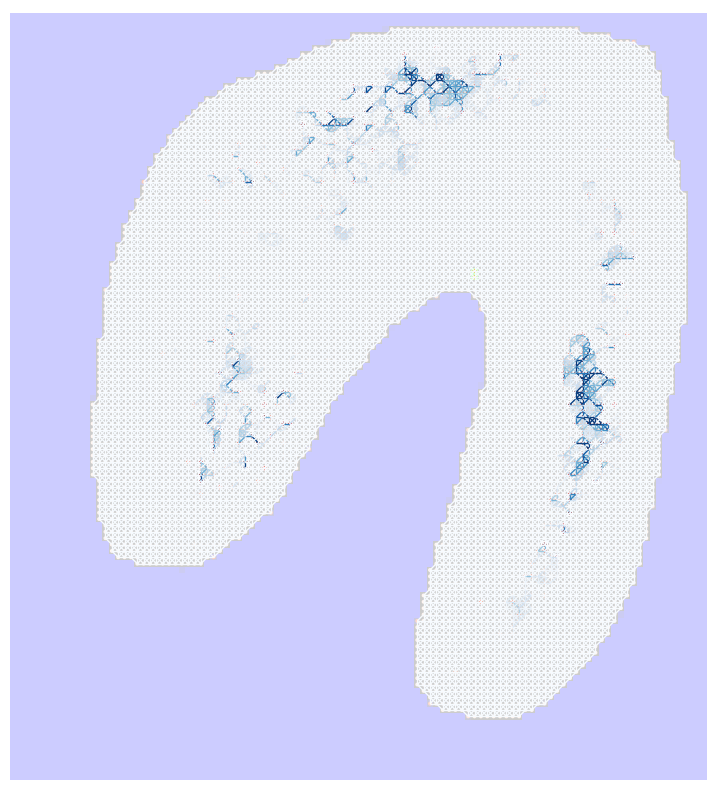

In [4]:
from visualisation import visualise_network
visualise_network(nodes,adj,image,im_alpha=0.2,node_size=0.2,edge_width=1)

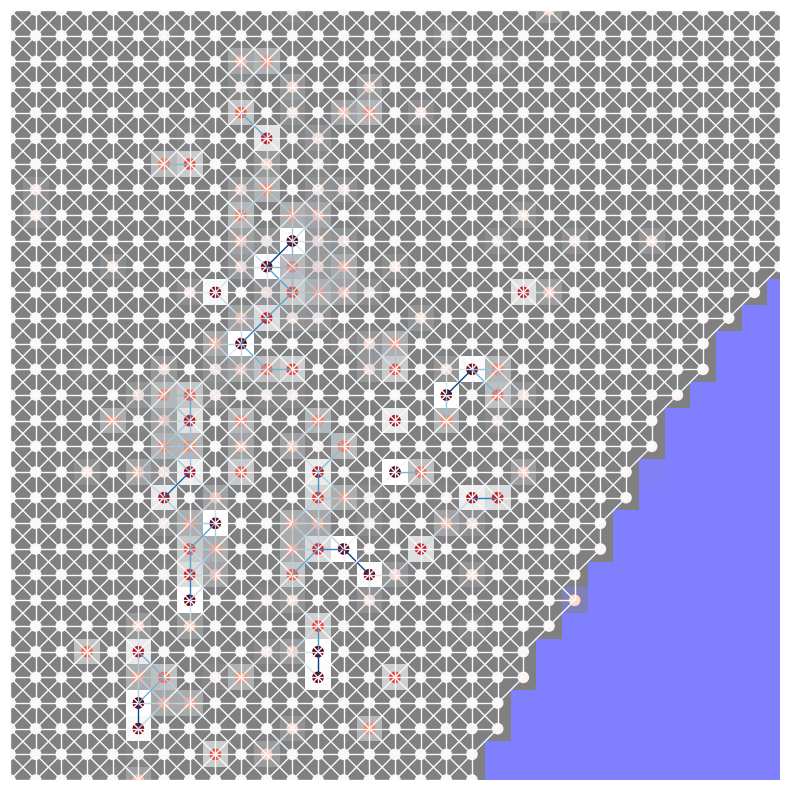

In [3]:
from visualisation import visualise_network
visualise_network(nodes,adj,image,im_alpha=0.5,node_size=0.2,edge_width=1,coords=[25,45],size=[30,30])

       x   y       type  weight
3744  73  79  posterior     0.0
3745  73  80  posterior     0.0
Network generation finished


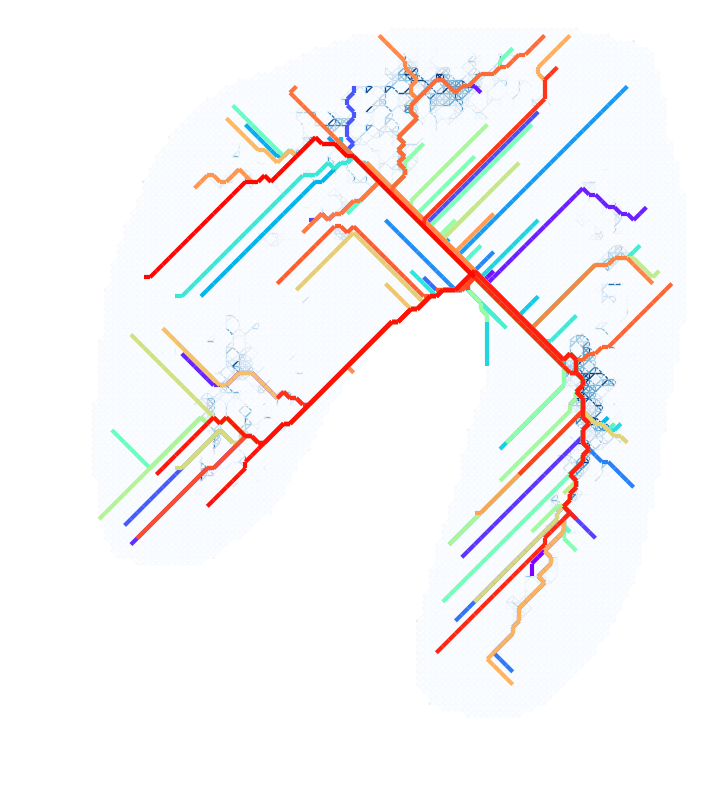

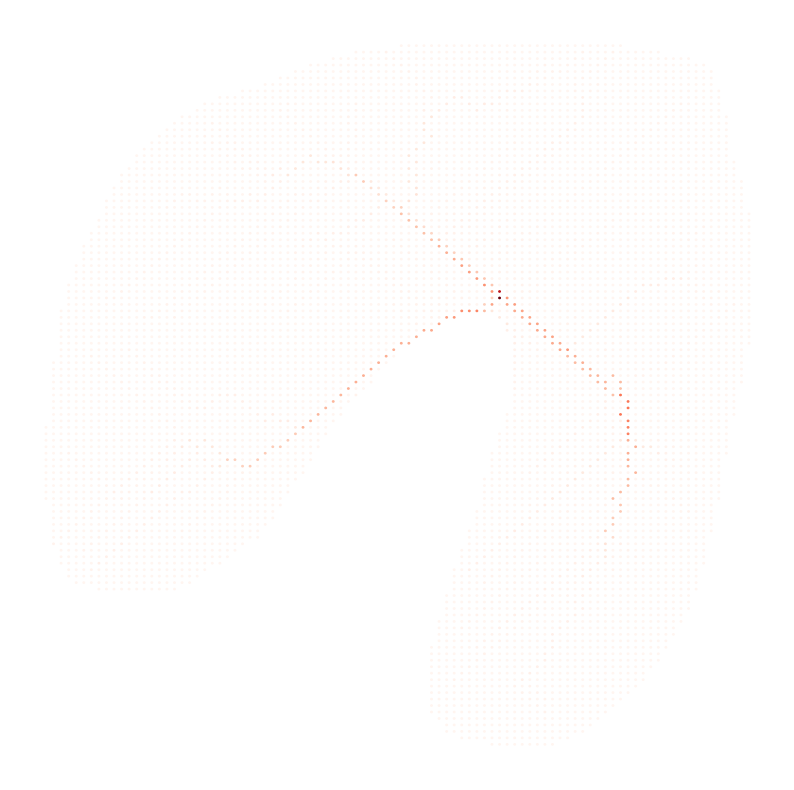

In [4]:
print(nodes[nodes["type"]=="posterior"])
paths.stochastic_paths(nodes,adj,100,image=image, display_paths=True, display_treads=True,start_type="posterior")

In [ ]:
#old code below
def process_new_treads(net,path_tread,particles):
    path_tread = path_tread/max(path_tread)
    
    for i in path_tread.index:
        if path_tread.loc[i]>0:
            nx.set_node_attributes(net,{i:path_tread.loc[i]*25+5},name="size")
        else: 
            nx.set_node_attributes(net,{i:0},name="size")

        if path_tread.loc[i]>0 and i not in particles:
            nx.set_node_attributes(net,{i:3},name="group")
    nx.set_node_attributes(net,"",name="label")
    return net